🐍 Starting Data Exploration...
📊 Loading cleaned data...
✅ Train data: (12516, 18)
✅ Validation data: (2682, 18)
✅ Test data: (2682, 18)

🔍 Dataset Info:
Columns available:
  1. job_id
  2. title
  3. location
  4. department
  5. salary_range
  6. company_profile
  7. description
  8. requirements
  9. benefits
  10. telecommuting
  11. has_company_logo
  12. has_questions
  13. employment_type
  14. required_experience
  15. required_education
  16. industry
  17. function
  18. fraudulent

🎯 Class Distribution:
Train:
  Real jobs: 11910 (95.2%)
  Fake jobs: 606 (4.8%)
Validation:
  Real jobs: 2552 (95.2%)
  Fake jobs: 130 (4.8%)
Test:
  Real jobs: 2552 (95.2%)
  Fake jobs: 130 (4.8%)

📊 Visualizing Class Distribution...


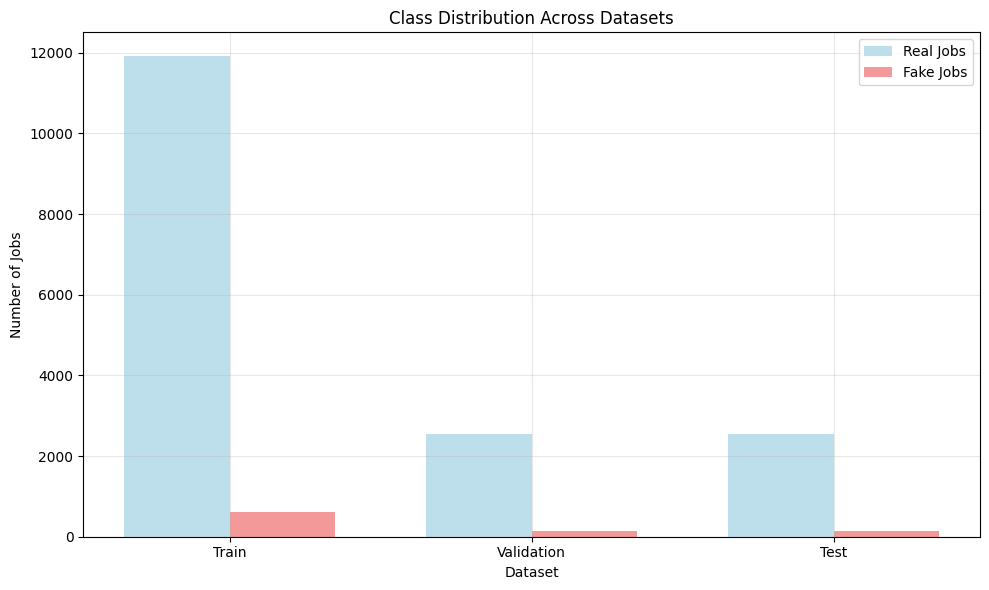


🔍 Missing Values in Training Data:
  location: 252 missing values (2.0%)
  department: 8104 missing values (64.7%)
  salary_range: 10558 missing values (84.4%)
  company_profile: 2315 missing values (18.5%)
  description: 1 missing values (0.0%)
  requirements: 1887 missing values (15.1%)
  benefits: 5118 missing values (40.9%)
  employment_type: 2429 missing values (19.4%)
  required_experience: 4925 missing values (39.3%)
  required_education: 5680 missing values (45.4%)
  industry: 3460 missing values (27.6%)
  function: 4541 missing values (36.3%)

📝 Text Columns Overview:

TITLE:
  Non-empty: 12516 (100.0%)
  Avg length: 27 characters
  Sample: technical manager...

COMPANY_PROFILE:
  Non-empty: 10201 (81.5%)
  Avg length: 720 characters
  Sample: luxury british cocoa grower and chocolatier hotel chocolat was founded in to make exciting chocolate...

DESCRIPTION:
  Non-empty: 12515 (100.0%)
  Avg length: 1144 characters
  Sample: to own and drive compliance of a safe legal qualit

In [1]:
# Data Exploration Notebook - Simplified Version
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

print("🐍 Starting Data Exploration...")
print("=" * 50)

# Load the cleaned data
print("📊 Loading cleaned data...")
train_data = pd.read_csv('../data/processed/train_data.csv')
val_data = pd.read_csv('../data/processed/val_data.csv')
test_data = pd.read_csv('../data/processed/test_data.csv')

print(f"✅ Train data: {train_data.shape}")
print(f"✅ Validation data: {val_data.shape}")
print(f"✅ Test data: {test_data.shape}")

# Basic information
print("\n🔍 Dataset Info:")
print("Columns available:")
for i, col in enumerate(train_data.columns, 1):
    print(f"  {i}. {col}")

# Check class distribution
print("\n🎯 Class Distribution:")
def print_class_distribution(data, name):
    real_jobs = len(data[data['fraudulent'] == 0])
    fake_jobs = len(data[data['fraudulent'] == 1])
    total = len(data)
    print(f"{name}:")
    print(f"  Real jobs: {real_jobs} ({real_jobs/total*100:.1f}%)")
    print(f"  Fake jobs: {fake_jobs} ({fake_jobs/total*100:.1f}%)")

print_class_distribution(train_data, "Train")
print_class_distribution(val_data, "Validation")
print_class_distribution(test_data, "Test")

# Visualize class distribution (simple matplotlib version)
print("\n📊 Visualizing Class Distribution...")
plt.figure(figsize=(10, 6))

datasets = ['Train', 'Validation', 'Test']
real_counts = [
    len(train_data[train_data['fraudulent'] == 0]),
    len(val_data[val_data['fraudulent'] == 0]),
    len(test_data[test_data['fraudulent'] == 0])
]
fake_counts = [
    len(train_data[train_data['fraudulent'] == 1]),
    len(val_data[val_data['fraudulent'] == 1]),
    len(test_data[test_data['fraudulent'] == 1])
]

x = np.arange(len(datasets))
width = 0.35

plt.bar(x - width/2, real_counts, width, label='Real Jobs', alpha=0.8, color='lightblue')
plt.bar(x + width/2, fake_counts, width, label='Fake Jobs', alpha=0.8, color='lightcoral')

plt.xlabel('Dataset')
plt.ylabel('Number of Jobs')
plt.title('Class Distribution Across Datasets')
plt.xticks(x, datasets)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Check missing values
print("\n🔍 Missing Values in Training Data:")
missing_values = train_data.isnull().sum()
missing_values = missing_values[missing_values > 0]

if len(missing_values) > 0:
    for col, count in missing_values.items():
        print(f"  {col}: {count} missing values ({(count/len(train_data)*100):.1f}%)")
else:
    print("  ✅ No missing values!")

# Examine text columns
print("\n📝 Text Columns Overview:")
text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']

for col in text_columns:
    if col in train_data.columns:
        non_empty = train_data[col].notna().sum()
        avg_length = train_data[col].str.len().mean() if non_empty > 0 else 0
        print(f"\n{col.upper()}:")
        print(f"  Non-empty: {non_empty} ({(non_empty/len(train_data)*100):.1f}%)")
        print(f"  Avg length: {avg_length:.0f} characters")
        
        # Show a sample
        sample = train_data[col].dropna().iloc[0] if non_empty > 0 else "No data"
        print(f"  Sample: {str(sample)[:100]}...")

# Numeric features analysis
print("\n🔢 Numeric Features Analysis:")
numeric_features = ['telecommuting', 'has_company_logo', 'has_questions']

if all(feature in train_data.columns for feature in numeric_features):
    print("\nNumeric Features Summary:")
    for feature in numeric_features:
        print(f"\n{feature}:")
        print(f"  Mean: {train_data[feature].mean():.3f}")
        print(f"  Std: {train_data[feature].std():.3f}")
        print(f"  Min: {train_data[feature].min()}")
        print(f"  Max: {train_data[feature].max()}")
        
        # Check correlation with target
        if feature != 'fraudulent':
            correlation = train_data[feature].corr(train_data['fraudulent'])
            print(f"  Correlation with fraudulent: {correlation:.3f}")

# Basic statistics
print("\n📈 Basic Statistics:")
print(f"Total jobs: {len(train_data) + len(val_data) + len(test_data)}")
print(f"Total fake jobs: {train_data['fraudulent'].sum() + val_data['fraudulent'].sum() + test_data['fraudulent'].sum()}")
print(f"Overall fraud rate: {(train_data['fraudulent'].sum() + val_data['fraudulent'].sum() + test_data['fraudulent'].sum()) / (len(train_data) + len(val_data) + len(test_data)) * 100:.1f}%")

print("\n" + "=" * 50)
print("✅ Data exploration complete!")
print("📝 Next step: Build machine learning models!")